# <a id="#">Task 3 – Mean, median, and Gaussian filtering</a>

In [1]:
import numpy
import matplotlib.pyplot as plt

---

## Linear filtering by convolution (mean filter)

**<a id="#">Task 3.1.1.</a>** Load the image `data/astronaut.png` and show it:

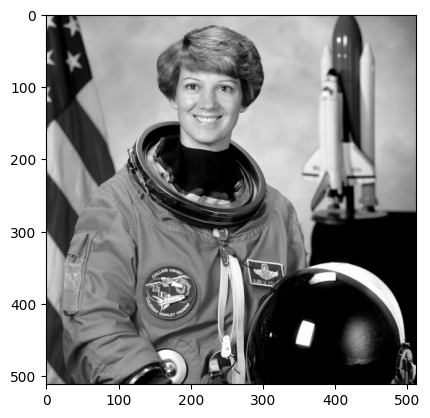

In [5]:
img=plt.imread('data/astronaut.png')
plt.imshow(img,'gray')


**<a id="#">Task 3.1.2.</a>** Implement a mean filter:

In [12]:
def meanfilter(img, size):
    result = np.zeros(img.shape, dtype=img.dtype)
    n = (size - 1) // 2

    if img.ndim == 2:
        for p in np.ndindex(img.shape):
            neighborhood_sum = 0
            count = 0
            for q in np.ndindex(size, size):
                y = p[0] + q[0] - n
                x = p[1] + q[1] - n
                if 0 <= y < img.shape[0] and 0 <= x < img.shape[1]:
                    neighborhood_sum += img[y, x]
                    count += 1
            result[p] = neighborhood_sum / count

**<a id="#">Task 3.1.3.</a>** Test your implementation from above by using the function `meanfilter` for the previously loaded image and show the result:

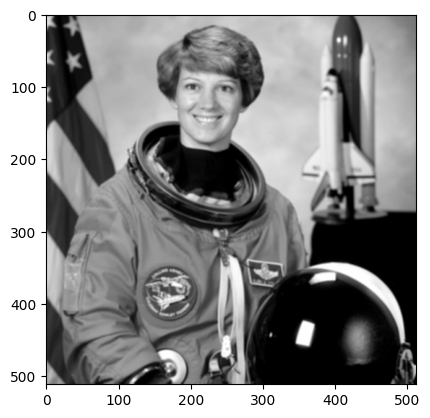

In [16]:
import numpy as np
def meanfilter(img, size):
    result = np.zeros(img.shape, dtype=img.dtype)
    n = (size - 1) // 2

    if img.ndim == 2:
        for p in np.ndindex(img.shape):
            neighborhood_sum = 0
            count = 0

            for q in np.ndindex(size, size):
                y = p[0] + q[0] - n
                x = p[1] + q[1] - n

                if 0 <= y < img.shape[0] and 0 <= x < img.shape[1]:
                    neighborhood_sum += img[y, x]
                    count += 1

            result[p] = neighborhood_sum / count

    return result

filtered = meanfilter(img, 3)

plt.imshow(filtered,'gray')
plt.show()


**<a id="#">Task 3.1.4.</a>** Compare your result for filter size `5` with the correct result image `data/astronaut_meanfilter5.png`:

In [20]:
import numpy as np
import matplotlib.pyplot as plt

img = plt.imread("data/astronaut.png")
correct = plt.imread("data/astronaut_meanfilter5.png")

filtered = meanfilter(img, 5)

filtered = filtered.astype(float)
correct = correct.astype(float)


n = 5 // 2  # =2


assert np.allclose(filtered[n:-n, n:-n], correct[n:-n, n:-n], atol=1/255)

---

## Non-linear filtering

**<a id="#">Task 3.2.1.</a>** Implement a median filter:

In [23]:
def medianfilter(img_in, size):
    result = numpy.zeros(img_in.shape)
    ...
    return result

**<a id="#">Task 3.2.2.</a>** First, test your implementation from above by using the function `medianfilter` for the previously loaded image and show the result:

In [25]:
import numpy as np  # falls noch nicht importiert

def medianfilter(img_in, size):
    result = np.zeros(img_in.shape, dtype=img_in.dtype)  # neues Bild für das Ergebnis
    n = size // 2  # Radius des Filters (für size=3 → n=1)
    
    # Über alle Pixel iterieren
    for p in np.ndindex(img_in.shape):
        neighborhood = []

        # Über das Filterfenster iterieren
        for q in np.ndindex((size, size)):
            y = p[0] + q[0] - n
            x = p[1] + q[1] - n
            
            # prüfen, ob wir innerhalb des Bildes sind
            if 0 <= y < img_in.shape[0] and 0 <= x < img_in.shape[1]:
                neighborhood.append(img_in[y, x])
        
        # Median berechnen
        result[p] = np.median(neighborhood)
    
    return result

Then, compare your result for filter size `5` with the correct result image `data/astronaut_medianfilter5.png`:

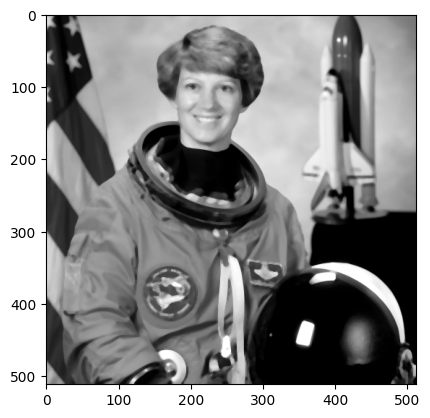

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Bilder laden
img = plt.imread("data/astronaut.png")
correct = plt.imread("data/astronaut_medianfilter5.png")

# Medianfilter-Funktion
def medianfilter(img_in, size):
    result = np.zeros(img_in.shape, dtype=img_in.dtype)
    n = size // 2

    for p in np.ndindex(img_in.shape):
        neighborhood = []
        for q in np.ndindex(size, size):
            y = p[0] + q[0] - n
            x = p[1] + q[1] - n
            if 0 <= y < img_in.shape[0] and 0 <= x < img_in.shape[1]:
                neighborhood.append(img_in[y, x])
        result[p] = np.median(neighborhood)
    
    return result

# Filter anwenden
filtered = medianfilter(img, 5)

# In float konvertieren für Vergleich
filtered = filtered.astype(float)
correct = correct.astype(float)

# Rand ignorieren (2 Pixel bei Filtergröße 5)
n = 5 // 2
assert np.allclose(filtered[n:-n, n:-n], correct[n:-n, n:-n], atol=1/255)

# Optional: Ergebnis anzeigen
plt.imshow(filtered, cmap='gray')
plt.show()

---

## Using pre-implemented filters

**<a id="#">Task 3.3.1.</a>** Load the package `scipy.ndimage`:

In [29]:
import scipy.ndimage

**<a id="#">Task 3.3.2 (a).</a>** Apply a **mean filter** from `scipy.ndimage` to the loaded image:

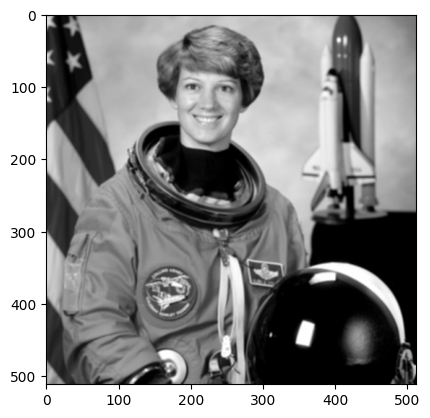

In [40]:
scipy.ndimage.uniform_filter(img, 3) 

plt.imshow(scipy.ndimage.uniform_filter(img, 3) , 'gray')


**<a id="#">Task 3.3.2 (b).</a>** Apply a **median filter** from `scipy.ndimage` to the loaded image:

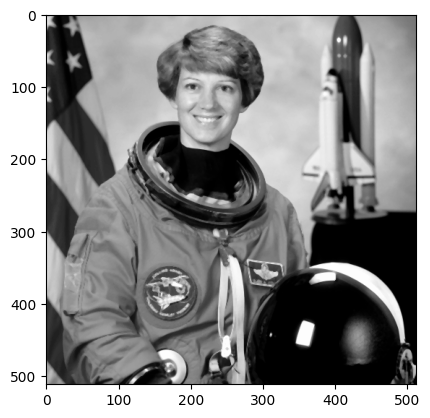

In [44]:
scipy.ndimage.median_filter(img, 3) 

plt.imshow(scipy.ndimage.median_filter(img, 3) , 'gray')

**<a id="#">Task 3.3.2 (c).</a>** Apply a **Gaussian filter** from `scipy.ndimage` to the loaded image:

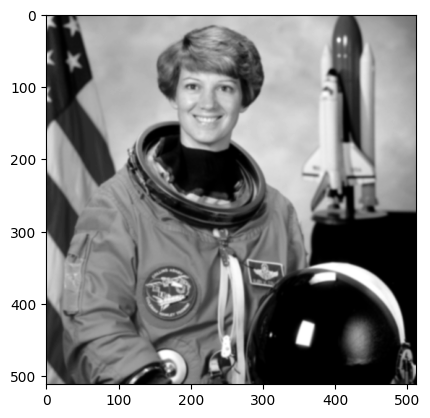

In [48]:
scipy.ndimage.gaussian_filter(img, 1) 

plt.imshow(scipy.ndimage.gaussian_filter(img, 1) , 'gray')

**<a id="#">Task 3.3.3.</a>** Compare the results obtained using the functions from `scipy.ndimage` with those you obtained using your own implementations. What are the main differences? Do you have an explanation?

In [ ]:
Optimierte Versionen, die Padding und Ränder automatisch behandeln

### Vergleich der Filter

Die SciPy-Implementierungen der Filter (uniform_filter, median_filter, gaussian_filter) sind optimiert und behandeln die Randpixel automatisch durch Padding. 

Im Vergleich zu unseren selbst implementierten Filtern:

- Die Ränder wirken bei SciPy-Filter glatter, da sie Padding verwenden. 
- Unsere eigenen Filter berechnen die Ränder oft nur aus den vorhandenen Nachbarn, was kleine Unterschiede erzeugt.
- Die SciPy-Filter sind deutlich schneller.
- Der Medianfilter entfernt Ausreißer sauberer, der Mittelwertfilter glättet gleichmäßig.
- Der Gaußfilter erzeugt weiche Übergänge, die bei größeren Sigma-Werten stärker glätten.


---

## Slicing and benchmarking

**<a id="#">Task 3.4.2.</a>** Implement either a mean filter or a median filter using only a single `for`-loop:

In [49]:
def fastfilter(img_in, size):
    ...

**<a id="#">Task 3.4.3.</a>** First, test your implementation from above by using the function `fastfilter` for the previously loaded image and show the result:

Then, compare your result to those obtained using your implementation for either `meanfilter` or `medianfilter`, respectively:

**<a id="#">Task 3.4.4.</a>** Benchmark the code run times:

**<a id="#">Task 3.4.5.</a>** Document your observations regarding the benchmarking results and try to think of an explanation: